# Sauvie Island weekly unit harvest trends

This notebook opens the committed DuckDB database and starts with the requested historical chart: five-season duck harvest efficiency by unit, week, and area. Efficiency is calculated as total ducks divided by total hunters, so larger units do not rank highly merely because they accommodate more hunters.

Source coverage: 256 ODFW hunt dates from 2021-22 through 2025-26.

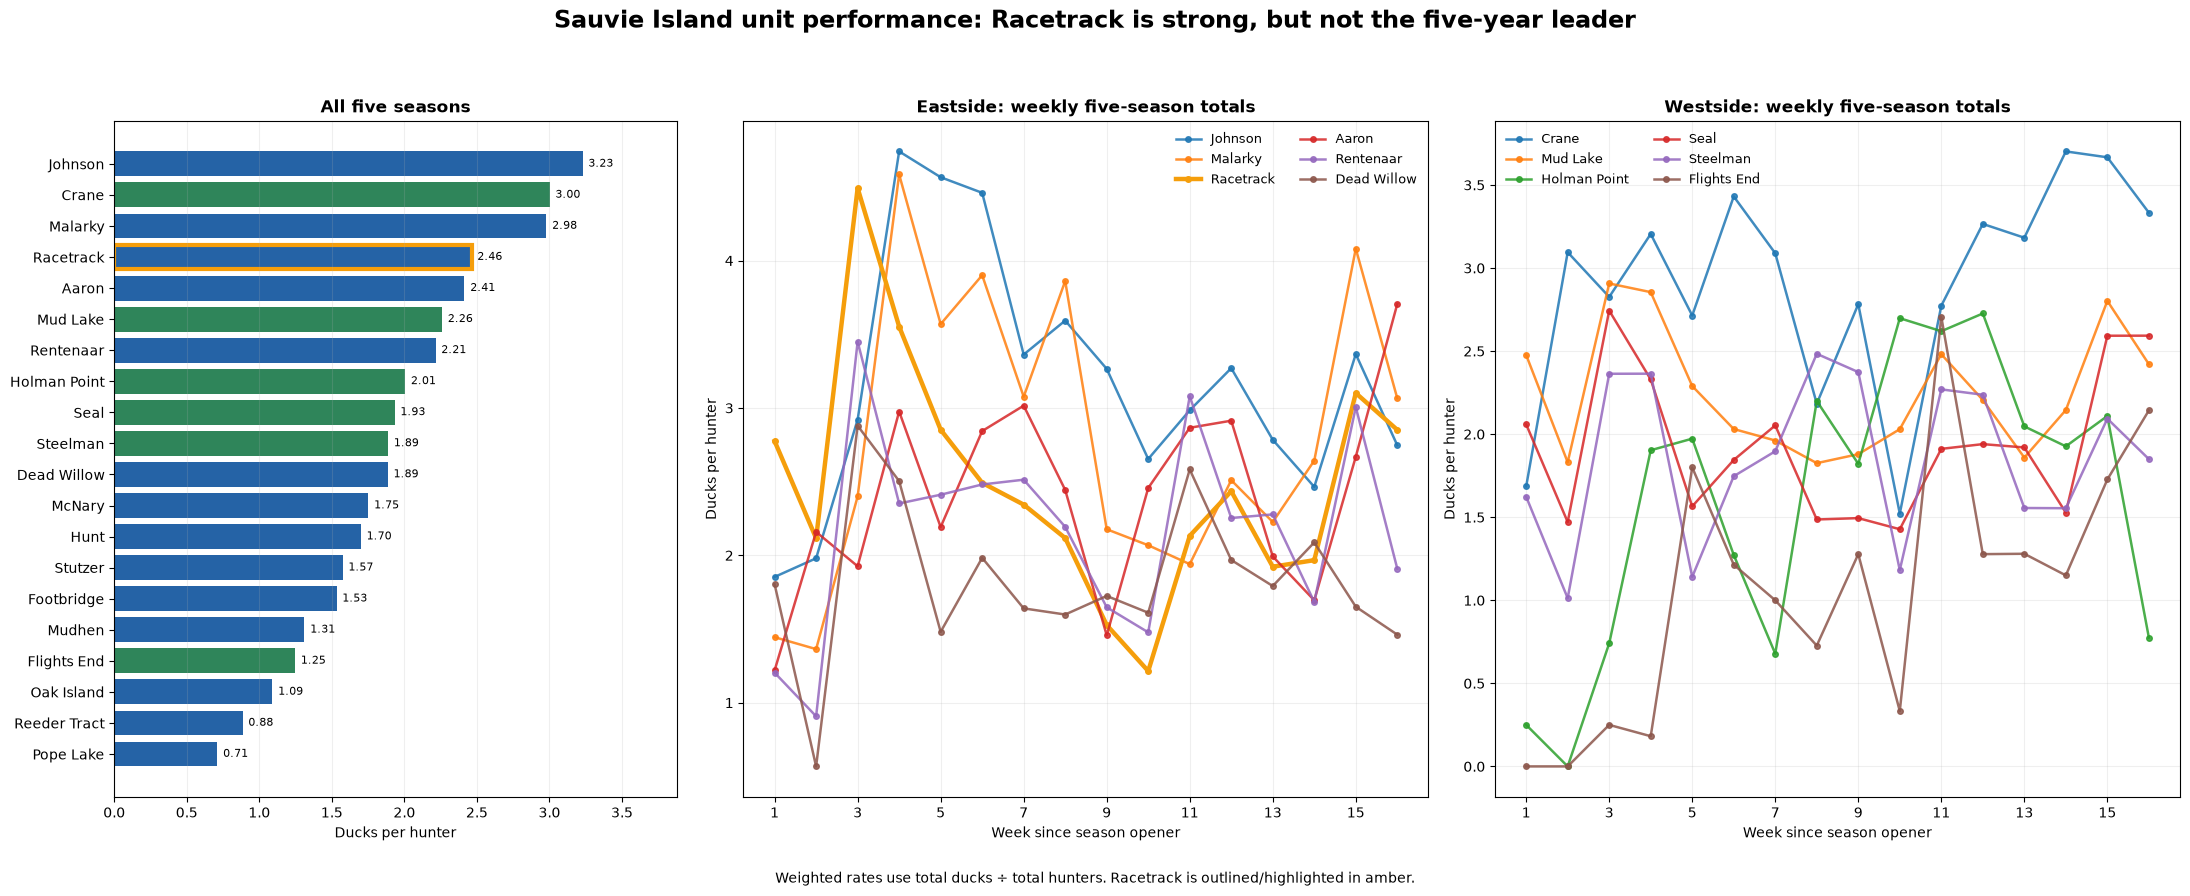

In [1]:
# Load the analytical database and produce the requested first chart.
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "processed" / "duckit_oregon.duckdb"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

con = duckdb.connect(str(DB_PATH), read_only=True)

overall = con.sql("""
    SELECT area, unit, hunters, ducks, ducks_per_hunter
    FROM all_seasons_unit_harvest
    WHERE hunters >= 100
    ORDER BY ducks_per_hunter
""").df()

weekly = con.sql("""
    SELECT
        season_week,
        area,
        unit,
        SUM(hunters) AS hunters,
        SUM(ducks) AS ducks,
        SUM(ducks)::DOUBLE / NULLIF(SUM(hunters), 0) AS ducks_per_hunter
    FROM harvest_daily_unit
    GROUP BY season_week, area, unit
    ORDER BY area, unit, season_week
""").df()

area_colors = {"Eastside": "#2563a6", "Westside": "#2f855a"}
fig, axes = plt.subplots(
    1, 3, figsize=(22, 9), gridspec_kw={"width_ratios": [1.15, 1.4, 1.4]}
)

# Five-season unit ranking.
bar_colors = [area_colors[area] for area in overall["area"]]
bars = axes[0].barh(overall["unit"], overall["ducks_per_hunter"], color=bar_colors)
for bar, unit, value in zip(bars, overall["unit"], overall["ducks_per_hunter"]):
    if unit == "Racetrack":
        bar.set_edgecolor("#f59e0b")
        bar.set_linewidth(3)
    axes[0].text(value + 0.04, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", fontsize=8)
axes[0].set_title("All five seasons", fontweight="bold")
axes[0].set_xlabel("Ducks per hunter")
axes[0].set_xlim(0, overall["ducks_per_hunter"].max() + 0.65)
axes[0].grid(axis="x", alpha=0.2)

# Weekly trends for the six strongest units in each area.
for axis, area in zip(axes[1:], ["Eastside", "Westside"]):
    leaders = (
        overall.loc[overall["area"] == area]
        .nlargest(6, "ducks_per_hunter")["unit"]
        .tolist()
    )
    for index, unit in enumerate(leaders):
        values = weekly.loc[(weekly["area"] == area) & (weekly["unit"] == unit)]
        highlight = unit == "Racetrack"
        axis.plot(
            values["season_week"],
            values["ducks_per_hunter"],
            marker="o",
            markersize=4,
            linewidth=3.2 if highlight else 1.8,
            color="#f59e0b" if highlight else plt.cm.tab10(index),
            label=unit,
            alpha=1.0 if highlight else 0.85,
        )
    axis.set_xticks(np.arange(1, int(weekly["season_week"].max()) + 1, 2))
    axis.set_title(f"{area}: weekly five-season totals", fontweight="bold")
    axis.set_xlabel("Week since season opener")
    axis.set_ylabel("Ducks per hunter")
    axis.grid(alpha=0.2)
    axis.legend(frameon=False, ncol=2, fontsize=9)

fig.suptitle(
    "Sauvie Island unit performance: Racetrack is strong, but not the five-year leader",
    fontsize=17,
    fontweight="bold",
)
fig.text(
    0.5,
    0.01,
    "Weighted rates use total ducks ÷ total hunters. Racetrack is outlined/highlighted in amber.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=[0, 0.04, 1, 0.94])
fig.savefig(ARTIFACTS / "weekly-unit-harvest.png", dpi=180, bbox_inches="tight")
plt.show()

## Does Racetrack lead over time?

The next view ranks Eastside units independently in each season. Units with fewer than 50 hunters in a season are omitted from that season's ranking to avoid presenting tiny samples as stable performance.

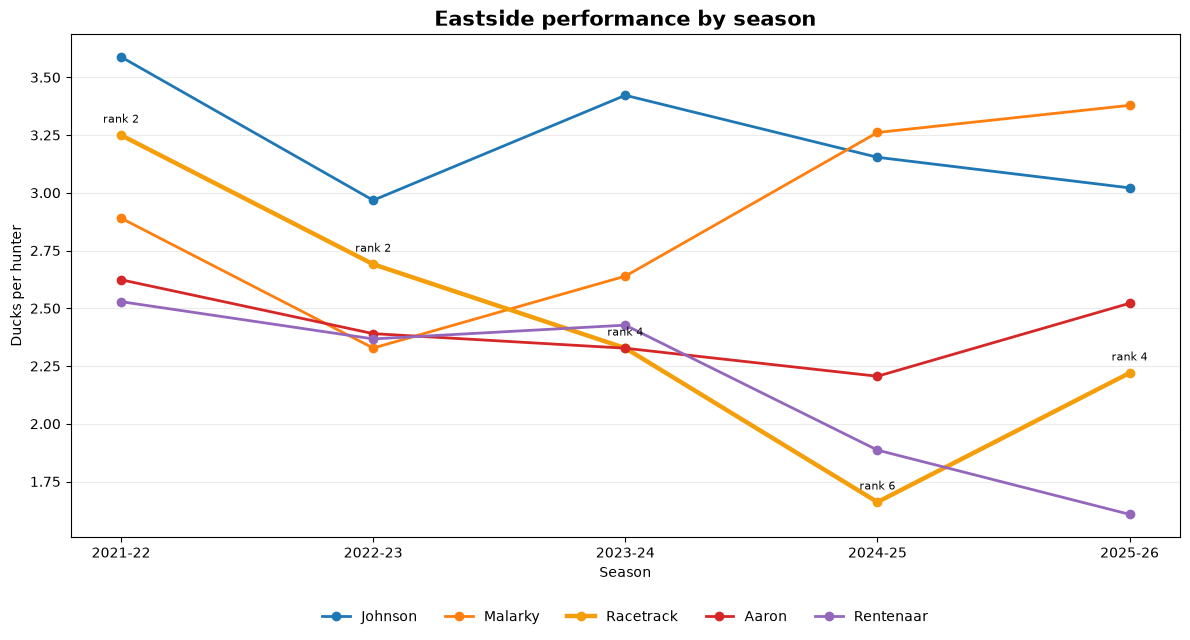

,season,hunters,ducks,ducks_per_hunter,eastside_rank
1,2021-22,689,2239,3.25,2
14,2022-23,705,1897,2.69,2
29,2023-24,690,1606,2.33,4
44,2024-25,575,955,1.66,6
54,2025-26,609,1352,2.22,4


In [2]:
# Compare the strongest Eastside units season by season.
season_performance = con.sql("""
    WITH eligible AS (
        SELECT season, area, unit, hunters, ducks, ducks_per_hunter
        FROM season_unit_harvest
        WHERE area = 'Eastside' AND hunters >= 50
    )
    SELECT
        *,
        RANK() OVER (
            PARTITION BY season ORDER BY ducks_per_hunter DESC NULLS LAST
        ) AS eastside_rank
    FROM eligible
    ORDER BY season, eastside_rank
""").df()

top_eastside = (
    overall.loc[overall["area"] == "Eastside"]
    .nlargest(5, "ducks_per_hunter")["unit"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(12, 6.5))
for index, unit in enumerate(top_eastside):
    values = season_performance.loc[season_performance["unit"] == unit]
    highlight = unit == "Racetrack"
    ax.plot(
        values["season"],
        values["ducks_per_hunter"],
        marker="o",
        linewidth=3.2 if highlight else 2,
        color="#f59e0b" if highlight else plt.cm.tab10(index),
        label=unit,
    )
    if highlight:
        for row in values.itertuples():
            ax.annotate(
                f"rank {row.eastside_rank}",
                (row.season, row.ducks_per_hunter),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                fontsize=8,
            )
ax.set_title("Eastside performance by season", fontsize=15, fontweight="bold")
ax.set_ylabel("Ducks per hunter")
ax.set_xlabel("Season")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
fig.savefig(ARTIFACTS / "unit-season-consistency.png", dpi=180, bbox_inches="tight")
plt.show()

racetrack_history = season_performance.loc[
    season_performance["unit"] == "Racetrack",
    ["season", "hunters", "ducks", "ducks_per_hunter", "eastside_rank"],
].copy()
racetrack_history["ducks_per_hunter"] = racetrack_history["ducks_per_hunter"].round(2)
racetrack_history

## Finding

Racetrack is a strong unit, but the five-season data does **not** support calling it the best unit overall.

- Racetrack produced 8,049 ducks for 3,268 hunters: **2.46 ducks per hunter**.
- Johnson produced 9,917 ducks for 3,072 hunters: **3.23 ducks per hunter**, the best five-season Eastside rate among units with at least 100 hunters.
- Malarky was also ahead of Racetrack at **2.98 ducks per hunter**, although on less than half Racetrack's hunter volume.
- Racetrack ranked 2nd, 2nd, 4th, 6th, and 4th among eligible Eastside units across the five seasons. Its reputation fits 2021-22 and 2022-23 better than the three most recent seasons.

These are observational harvest records, not a controlled estimate of blind quality. Hunter selection, unit capacity, weather, access, and hunter skill can all affect the rates.

## Database inventory

The database also keeps the processed weather, raw Open-Meteo JSON, complete ODFW source manifest, and reservation-report source catalog for later analyses.

In [3]:
inventory = con.sql("""
    SELECT 'harvest_daily_unit' AS object, COUNT(*) AS rows FROM harvest_daily_unit
    UNION ALL
    SELECT 'hunt_day_weather', COUNT(*) FROM hunt_day_weather
    UNION ALL
    SELECT 'reservation_first_choice_application', COUNT(*)
    FROM reservation_first_choice_application
    UNION ALL
    SELECT 'odfw_source_manifest', COUNT(*) FROM odfw_source_manifest
    UNION ALL
    SELECT 'weather_raw_response', COUNT(*) FROM weather_raw_response
    UNION ALL
    SELECT 'reservation_report_sources', COUNT(*) FROM reservation_report_sources
""").df()
inventory

,object,rows
0,harvest_daily_unit,5376
1,hunt_day_weather,256
2,odfw_source_manifest,302
3,weather_raw_response,5
4,reservation_report_sources,35
